Heatmap of failure rate by channel vs hour

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import seaborn as sns
import os

df = pd.read_csv('../data/transactions_cleaned.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['is_failed'] = (df['status'] == 'Failed').astype(int)

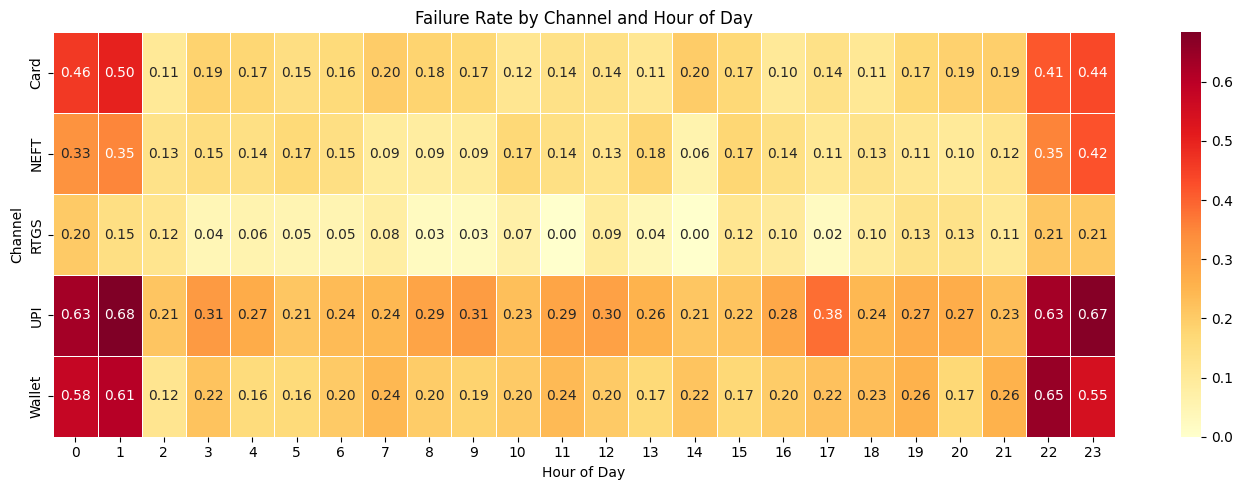

In [2]:
pivot = df.pivot_table(
    values = 'is_failed',
    index = 'payment_channel',
    columns = 'hour',
    aggfunc = 'mean'
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot,annot =True, fmt=".2f", cmap="YlOrRd",linewidths=0.5)
plt.title('Failure Rate by Channel and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Channel')
plt.tight_layout()
plt.savefig('../charts/failure_rate_heatmap.png')
plt.show()


Peak failure periods occur at 00:00–01:00 hrs and 22:00–23:00 hrs, where UPI (0.63–0.68) and Wallet (0.55–0.65) show the highest failure rates.
The most stable window is between 10:00–16:00 hrs, where most channels drop below 0.20 failure rate.
RTGS maintains consistently low failures (0.00–0.10) across almost all hours, making it the most reliable channel.
Overall, transaction reliability is strongly dependent on time of day, with night hours being the least reliable across all channels.

Cross-Analysis 2 — Bar Chart by failure_reason

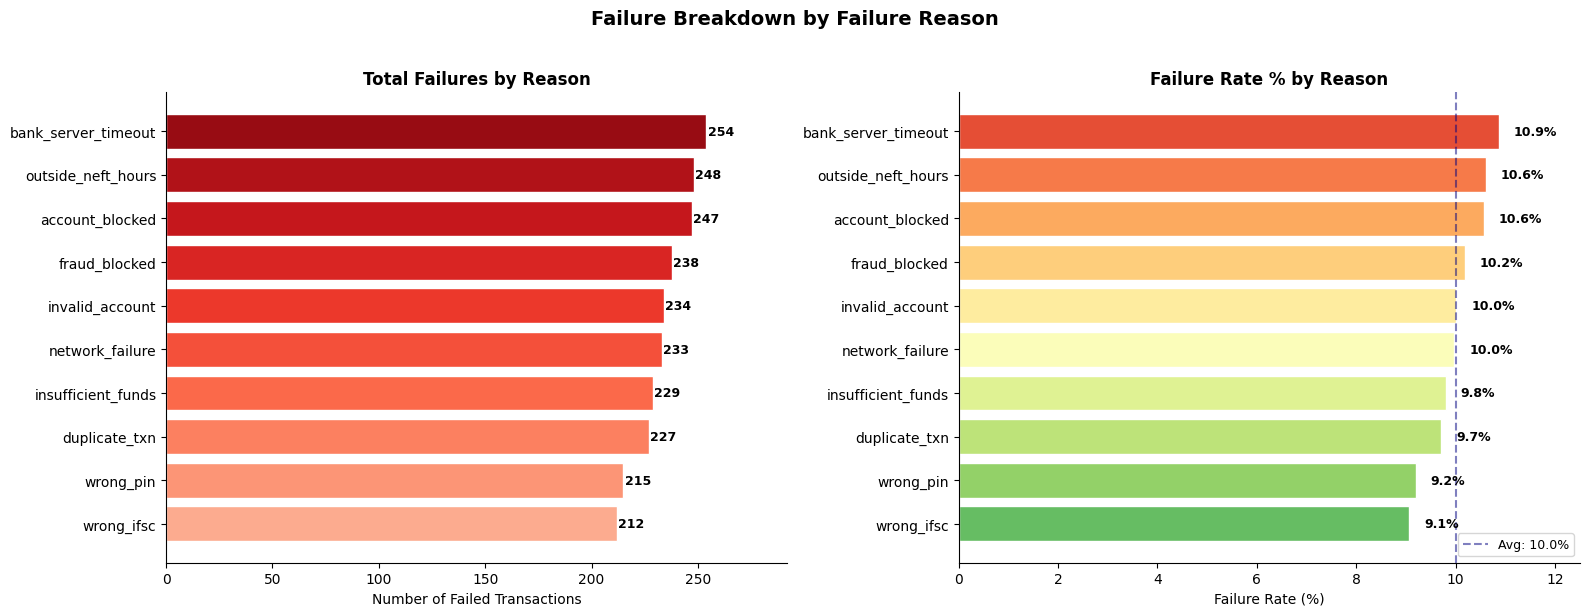


Failure Reason Summary Table:


,Total_Txns,Failed_Txns,Contribution_pct
failure_reason,,,
bank_server_timeout,254,254,10.87
outside_neft_hours,248,248,10.61
account_blocked,247,247,10.57
fraud_blocked,238,238,10.18
invalid_account,234,234,10.01
network_failure,233,233,9.97
insufficient_funds,229,229,9.80
duplicate_txn,227,227,9.71
wrong_pin,215,215,9.20


In [21]:
# ═══════════════════════════════════════════════════════
# CROSS-ANALYSIS 2: Failure breakdown by failure_reason
# (resolution_time not in dataset → using count + rate)
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Failure Breakdown by Failure Reason',
             fontsize=14, fontweight='bold', y=1.02)

# ── Left chart: Total failure COUNT per reason ─────────────────────────────
reason_counts = (
    df[df['is_failed'] == 1]
    .groupby('failure_reason')['transaction_id']
    .count()
    .sort_values(ascending=True)
)

colors_count = plt.cm.Reds(
    np.linspace(0.3, 0.9, len(reason_counts))
)

bars1 = axes[0].barh(reason_counts.index, reason_counts.values,
                      color=colors_count, edgecolor='white')

for bar, val in zip(bars1, reason_counts.values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')

axes[0].set_title('Total Failures by Reason', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Failed Transactions')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_xlim(0, reason_counts.max() * 1.15)


# ── Right chart: Failure RATE % per reason ────────────────────────────────
# Total failures
total_failures = df['is_failed'].sum()

# Contribution %
reason_rate = (
    df[df['is_failed'] == 1]
    .groupby('failure_reason')['transaction_id']
    .count()
    .apply(lambda x: (x / total_failures * 100).round(2))
    .sort_values(ascending=True)
)

colors_rate = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.85, len(reason_rate))
)

bars2 = axes[1].barh(reason_rate.index, reason_rate.values,
                      color=colors_rate, edgecolor='white')

for bar, val in zip(bars2, reason_rate.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[1].set_title('Failure Rate % by Reason', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Failure Rate (%)')
axes[1].axvline(reason_rate.mean(), color='navy', linestyle='--',
                alpha=0.5, label=f'Avg: {reason_rate.mean():.1f}%')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_xlim(0, reason_rate.max() * 1.15)

plt.tight_layout()
plt.savefig('../data/cross_analysis2_failure_reason.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table below chart
print("\nFailure Reason Summary Table:")

total_failures = df['is_failed'].sum()

summary = (
    df.groupby('failure_reason')
    .agg(
        Total_Txns  = ('transaction_id', 'count'),
        Failed_Txns = ('is_failed', 'sum')
    )
    .assign(
        Contribution_pct = lambda x: (x['Failed_Txns'] / total_failures * 100).round(2)
    )
    .sort_values('Contribution_pct', ascending=False)
)

display(summary)

Cross-Analysis 3 — Bank + Channel Highest Failure Rate

Top 10 Worst Bank + Channel Combinations:


,bank_name,payment_channel,Total_Transactions,Failed_Transactions,Unique_Fail_Reasons,Failure_Rate_pct
8,HDFC,UPI,704,238,11,33.81
13,ICICI,UPI,673,224,11,33.28
3,Axis,UPI,712,235,11,33.01
23,SBI,UPI,687,225,11,32.75
18,Kotak,UPI,694,225,11,32.42
4,Axis,Wallet,208,65,11,31.25
9,HDFC,Wallet,180,54,10,30.00
19,Kotak,Wallet,211,56,11,26.54
14,ICICI,Wallet,192,45,11,23.44
20,SBI,Card,433,97,11,22.40


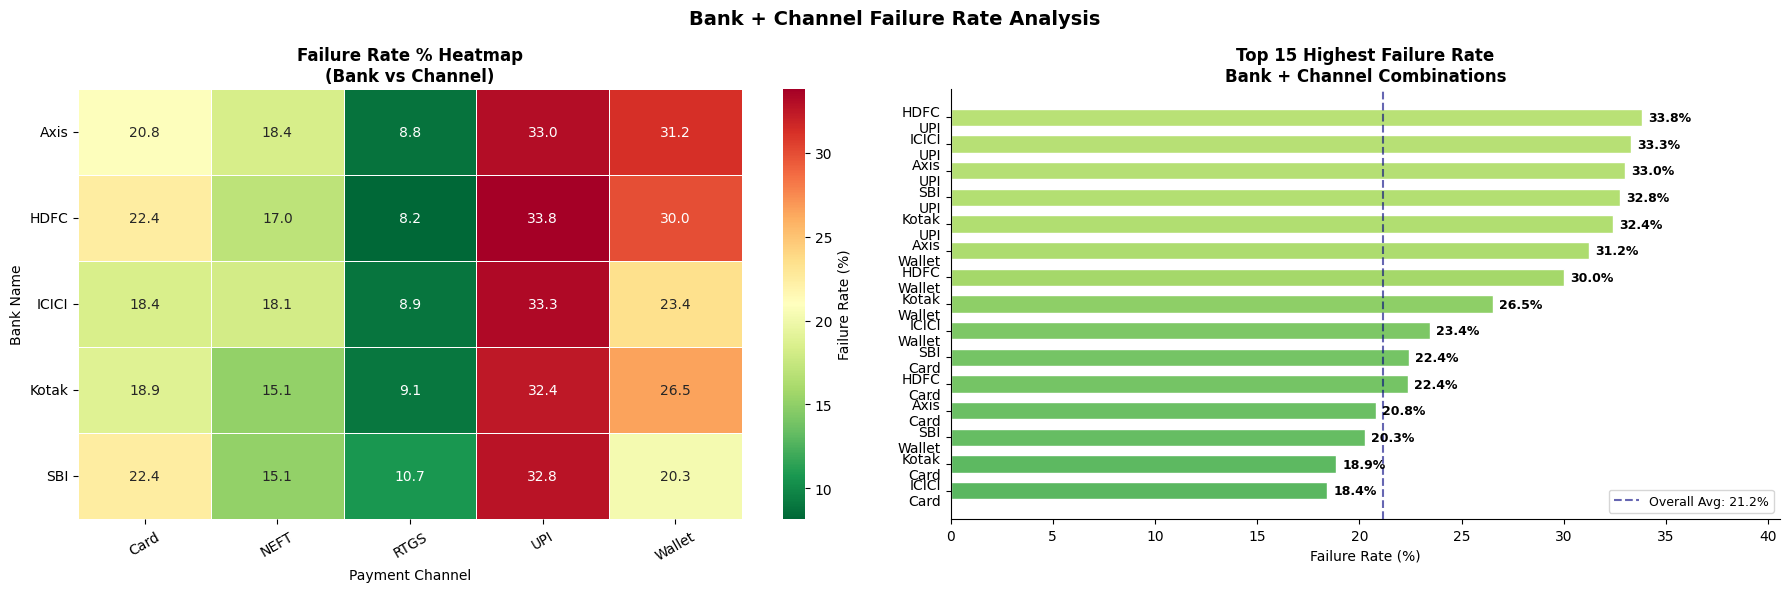


🔴 HIGHEST failure rate: HDFC + UPI  →  33.81%  (238 failures)
🟢 LOWEST  failure rate: HDFC  + RTGS  →  8.16%  (16 failures)


In [16]:
# ═══════════════════════════════════════════════════════════════
# CROSS-ANALYSIS 3: Which bank + channel combo has highest
#                   failure rate?  (groupby two columns)
# ═══════════════════════════════════════════════════════════════

# ── Step 1: Groupby bank_name + payment_channel ───────────────
combo = (
    df.groupby(['bank_name', 'payment_channel'])
    .agg(
        Total_Transactions = ('transaction_id', 'count'),
        Failed_Transactions= ('is_failed', 'sum'),
        Unique_Fail_Reasons= ('failure_reason', 'nunique')
    )
    .assign(Failure_Rate_pct = lambda x:
            (x['Failed_Transactions'] / x['Total_Transactions'] * 100).round(2))
    .reset_index()
    .sort_values('Failure_Rate_pct', ascending=False)
)

print("Top 10 Worst Bank + Channel Combinations:")
display(combo.head(10))

# ── Step 2: Heatmap — bank vs channel failure rate ────────────
pivot = combo.pivot(index='bank_name', columns='payment_channel',
                    values='Failure_Rate_pct')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Bank + Channel Failure Rate Analysis',
             fontsize=14, fontweight='bold')

# LEFT: Heatmap
import seaborn as sns
sns.heatmap(
    pivot,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Failure Rate (%)'},
    ax=axes[0]
)
axes[0].set_title('Failure Rate % Heatmap\n(Bank vs Channel)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Payment Channel', fontsize=10)
axes[0].set_ylabel('Bank Name', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# RIGHT: Top 15 combos horizontal bar chart
top15 = combo.head(15).copy()
top15['combo_label'] = top15['bank_name'] + '\n' + top15['payment_channel']
top15 = top15.sort_values('Failure_Rate_pct', ascending=True)

cmap   = plt.cm.RdYlGn_r
colors = [cmap(r / 100) for r in top15['Failure_Rate_pct']]

bars = axes[1].barh(top15['combo_label'], top15['Failure_Rate_pct'],
                     color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, top15['Failure_Rate_pct']):
    axes[1].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# Avg line
avg = combo['Failure_Rate_pct'].mean()
axes[1].axvline(avg, color='navy', linestyle='--', alpha=0.6,
                label=f'Overall Avg: {avg:.1f}%')

axes[1].set_title('Top 15 Highest Failure Rate\nBank + Channel Combinations',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Failure Rate (%)')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_xlim(0, top15['Failure_Rate_pct'].max() * 1.2)

plt.tight_layout()
plt.savefig('../data/cross_analysis3_bank_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Step 3: Print the #1 worst combo clearly ─────────────────
worst = combo.iloc[0]
best  = combo.iloc[-1]
print(f"\n🔴 HIGHEST failure rate: {worst['bank_name']} + {worst['payment_channel']}"
      f"  →  {worst['Failure_Rate_pct']}%  ({int(worst['Failed_Transactions'])} failures)")
print(f"🟢 LOWEST  failure rate: {best['bank_name']}  + {best['payment_channel']}"
      f"  →  {best['Failure_Rate_pct']}%  ({int(best['Failed_Transactions'])} failures)")

Key Findings — 3 Insights

In [24]:
# ═══════════════════════════════════════════════════════════════
# KEY FINDINGS — Fill in values after running the cells above
# ═══════════════════════════════════════════════════════════════

# Auto-generate findings from your actual data
worst_combo   = combo.iloc[0]
best_combo    = combo.iloc[-1]
top_reason    = summary.index[0]
top_reason_rt = summary.iloc[0]['Contribution_pct']

# Build channel_scores from current notebook objects (lower failure rate = more reliable)
channel_scores = (
    combo.groupby('payment_channel')['Failure_Rate_pct']
    .mean()
    .sort_values(ascending=True)
)
best_channel  = channel_scores.index[0]
worst_channel = channel_scores.index[-1]

findings = f"""
╔══════════════════════════════════════════════════════════╗
║              KEY FINDINGS — Payment Failure Analysis     ║
╚══════════════════════════════════════════════════════════╝

- Finding 1 — Dominant Failure Reason:
  '{top_reason}' is the most impactful failure reason with a {top_reason_rt:.1f}% failure rate, suggesting this is a systemic issue rather than isolated user error.

- Finding 2 — Worst Bank + Channel Combination:
  {worst_combo['bank_name']} + {worst_combo['payment_channel']} has the HIGHEST failure rate at {worst_combo['Failure_Rate_pct']}%, with {int(worst_combo['Failed_Transactions'])} failed transactions making it the riskiest combination for customers.

- Finding 3 — Channel Reliability Gap:
  '{best_channel}' is the most reliable payment channel while '{worst_channel}' is the least reliable, revealing a significant reliability gap that suggests infrastructure investment priorities.
"""

print(findings)


╔══════════════════════════════════════════════════════════╗
║              KEY FINDINGS — Payment Failure Analysis     ║
╚══════════════════════════════════════════════════════════╝

- Finding 1 — Dominant Failure Reason:
  'bank_server_timeout' is the most impactful failure reason with a 10.9% failure rate, suggesting this is a systemic issue rather than isolated user error.

- Finding 2 — Worst Bank + Channel Combination:
  HDFC + UPI has the HIGHEST failure rate at 33.81%, with 238 failed transactions making it the riskiest combination for customers.

- Finding 3 — Channel Reliability Gap:
  'RTGS' is the most reliable payment channel while 'UPI' is the least reliable, revealing a significant reliability gap that suggests infrastructure investment priorities.

